Test cell

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import morphological_geodesic_active_contour

# Configure matplotlib font fallback (kept for completeness)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

## Load the ROI image

`demo.png` already contains the ROI after extraction and context padding.

ROI 影像尺寸: (203, 300, 3)


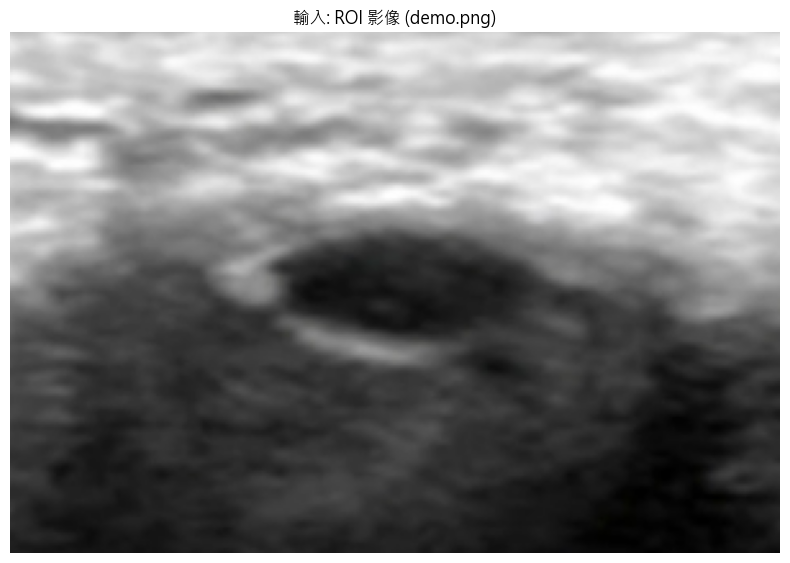

In [ ]:
# Load demo.png (ROI image)
roi = cv2.imread('demo.png')
roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

print(f"ROI image shape: {roi.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(roi)
plt.title('Input: ROI image (demo.png)')
plt.axis('off')
plt.tight_layout()
plt.savefig('0_input_roi.png', dpi=150, bbox_inches='tight')
plt.show()

## Helper function definitions

The following helpers are used throughout the segmentation pipeline.

In [ ]:
def ensure_gray(image: np.ndarray) -> np.ndarray:
    """Convert an image to normalized grayscale (0-1)."""
    if image.ndim == 2:
        gray = image
    else:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return cv2.normalize(gray, None, 0.0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)


def largest_component(mask: np.ndarray) -> np.ndarray:
    """Keep only the largest connected component."""
    mask = (mask > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(mask)
    if num_labels <= 2:
        return mask * 255
    areas = np.bincount(labels.ravel())
    areas[:1] = 0  # Ignore background label
    best_label = int(np.argmax(areas)) if areas.size > 1 else 0
    filtered = (labels == best_label).astype(np.uint8)
    return filtered * 255


def remove_boundary_components(mask: np.ndarray) -> np.ndarray:
    """Remove connected components that touch the boundary."""
    binary = (mask > 0).astype(np.uint8)
    if not np.any(binary):
        return binary
    num_labels, labels = cv2.connectedComponents(binary)
    if num_labels <= 1:
        return binary
    keep = np.zeros_like(binary)
    h, w = binary.shape
    for label in range(1, num_labels):
        component = labels == label
        if (component[0, :].any() or component[h - 1, :].any() or
            component[:, 0].any() or component[:, w - 1].any()):
            continue
        keep[component] = 1
    if keep.any():
        return keep
    return binary


def guided_filter(image: np.ndarray, guide: np.ndarray, radius: int = 4, eps: float = 1e-3) -> np.ndarray:
    """Edge-preserving guided filter."""
    I = image.astype(np.float32)
    p = guide.astype(np.float32)
    win_size = (radius * 2 + 1, radius * 2 + 1)

    mean_I = cv2.boxFilter(I, ddepth=-1, ksize=win_size, normalize=True)
    mean_p = cv2.boxFilter(p, ddepth=-1, ksize=win_size, normalize=True)
    mean_Ip = cv2.boxFilter(I * p, ddepth=-1, ksize=win_size, normalize=True)
    cov_Ip = mean_Ip - mean_I * mean_p
    mean_II = cv2.boxFilter(I * I, ddepth=-1, ksize=win_size, normalize=True)
    var_I = mean_II - mean_I * mean_I

    a = cov_Ip / (var_I + eps)
    mean_a = cv2.boxFilter(a, ddepth=-1, ksize=win_size, normalize=True)
    b = mean_p - a * mean_I
    mean_b = cv2.boxFilter(b, ddepth=-1, ksize=win_size, normalize=True)

    q = mean_a * I + mean_b
    return q

---
## Step 3: Initial segmentation (GrabCut)

GrabCut is a graph-cut-based segmentation algorithm that models foreground and background color distributions with Gaussian Mixture Models (GMMs).

### Principle:
1. **Initialize the mask**: mark the ROI border as background and an inner ellipse as foreground seeds.
2. **GMM modeling**: learn the foreground/background color distribution from the seed regions.
3. **Graph cut optimization**: solve for the optimal separating boundary.

In [ ]:
def run_grabcut_seed(roi: np.ndarray) -> tuple:
    """
    Run GrabCut and return intermediate results for visualization.
    
    Returns:
        seed_mask_vis: seed mask used for visualization
        foreground: GrabCut result mask
    """
    roi_h, roi_w = roi.shape[:2]
    
    # Step 3.1: initialize the seed mask
    seed_mask = np.full((roi_h, roi_w), cv2.GC_PR_FGD, dtype=np.uint8)
    
    # Step 3.2: mark the border as definite background
    ring = int(np.clip(min(roi_h, roi_w) * 0.05, 10, 20))
    if ring > 0:
        seed_mask[:ring, :] = cv2.GC_BGD
        seed_mask[-ring:, :] = cv2.GC_BGD
        seed_mask[:, :ring] = cv2.GC_BGD
        seed_mask[:, -ring:] = cv2.GC_BGD
    
    # Step 3.3: mark a center ellipse as definite foreground
    cx = roi_w // 2
    cy = roi_h // 2
    axis_x = max(2, int(roi_w * 0.15))
    axis_y = max(2, int(roi_h * 0.15))
    cv2.ellipse(seed_mask, (cx, cy), (axis_x, axis_y), 0, 0, 360, cv2.GC_FGD, -1)
    
    # Preserve a copy for visualization
    seed_mask_vis = seed_mask.copy()
    
    # Step 3.4: run GrabCut
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    
    roi_for_gc = cv2.cvtColor(roi, cv2.COLOR_RGB2BGR)
    
    try:
        cv2.grabCut(roi_for_gc, seed_mask, None, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_MASK)
    except cv2.error as e:
        print(f"GrabCut error: {e}")
        # Fallback to a doubled ellipse if GrabCut fails
        fallback = np.zeros((roi_h, roi_w), dtype=np.uint8)
        cv2.ellipse(fallback, (cx, cy), (axis_x * 2, axis_y * 2), 0, 0, 360, 255, -1)
        return seed_mask_vis, fallback
    
    # Extract the foreground mask
    foreground = np.where(
        (seed_mask == cv2.GC_FGD) | (seed_mask == cv2.GC_PR_FGD),
        255, 0
    ).astype(np.uint8)
    
    return seed_mask_vis, foreground


seed_mask_vis, grabcut_mask = run_grabcut_seed(roi)

print(f"GrabCut result: foreground pixels = {np.count_nonzero(grabcut_mask)}")

GrabCut 結果: 前景像素數 = 5639


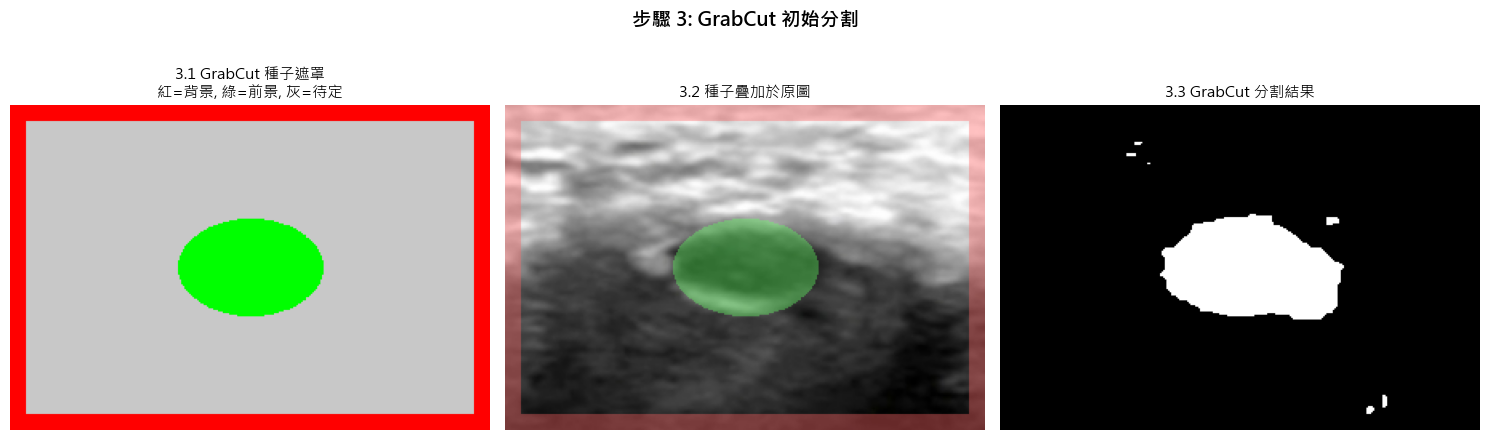

In [ ]:
# Visualize the GrabCut process
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Visualize seed mask
seed_colors = np.zeros((*seed_mask_vis.shape, 3), dtype=np.uint8)
seed_colors[seed_mask_vis == cv2.GC_BGD] = [255, 0, 0]      # Definite background - red
seed_colors[seed_mask_vis == cv2.GC_FGD] = [0, 255, 0]      # Definite foreground - green
seed_colors[seed_mask_vis == cv2.GC_PR_FGD] = [200, 200, 200]  # Probable foreground - gray

axes[0].imshow(seed_colors)
axes[0].set_title('3.1 GrabCut seed mask\nRed=background, Green=foreground, Gray=probable', fontsize=11)
axes[0].axis('off')

# Overlay seeds on original ROI
overlay = roi.copy()
overlay[seed_mask_vis == cv2.GC_BGD] = [255, 100, 100]
overlay[seed_mask_vis == cv2.GC_FGD] = [100, 255, 100]
blended = cv2.addWeighted(roi, 0.6, overlay, 0.4, 0)

axes[1].imshow(blended)
axes[1].set_title('3.2 Seeds overlaid on ROI', fontsize=11)
axes[1].axis('off')

# GrabCut result
axes[2].imshow(grabcut_mask, cmap='gray')
axes[2].set_title('3.3 GrabCut mask', fontsize=11)
axes[2].axis('off')

plt.suptitle('Step 3: GrabCut initialization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('1_grabcut_process.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 4: Contour refinement (MGAC)

Morphological Geodesic Active Contour (MGAC) is a morphology-inspired active contour algorithm.

### Principle:
1. **Edge detection**: detect image edges with the Canny operator.
2. **Compute weights**: edges yield low weights (high resistance) to stop the contour.
3. **Contour evolution**: the contour contracts inward like a deflating balloon until strong edges stop it.

### Key parameters:
- `balloon=-1`: inward pressure.
- `smoothing`: regularization strength.
- `init_level_set`: initialized with the GrabCut result.

In [ ]:
# Prepare MGAC inputs
roi_gray = ensure_gray(roi)

# Step 4.1: Canny edge detection
edges = cv2.Canny((roi_gray * 255).astype(np.uint8), 30, 80)

# Step 4.2: compute edge weights (strong edges => low weights to stop the contour)
edge_weight = np.exp(-(edges.astype(np.float32) / 255.0) * 10.0)
denom = float(np.ptp(edge_weight))
edge_weight = (edge_weight - edge_weight.min()) / (denom + 1e-6)

print(f"Edge weight range: [{edge_weight.min():.3f}, {edge_weight.max():.3f}]")

邊緣權重範圍: [0.000, 1.000]


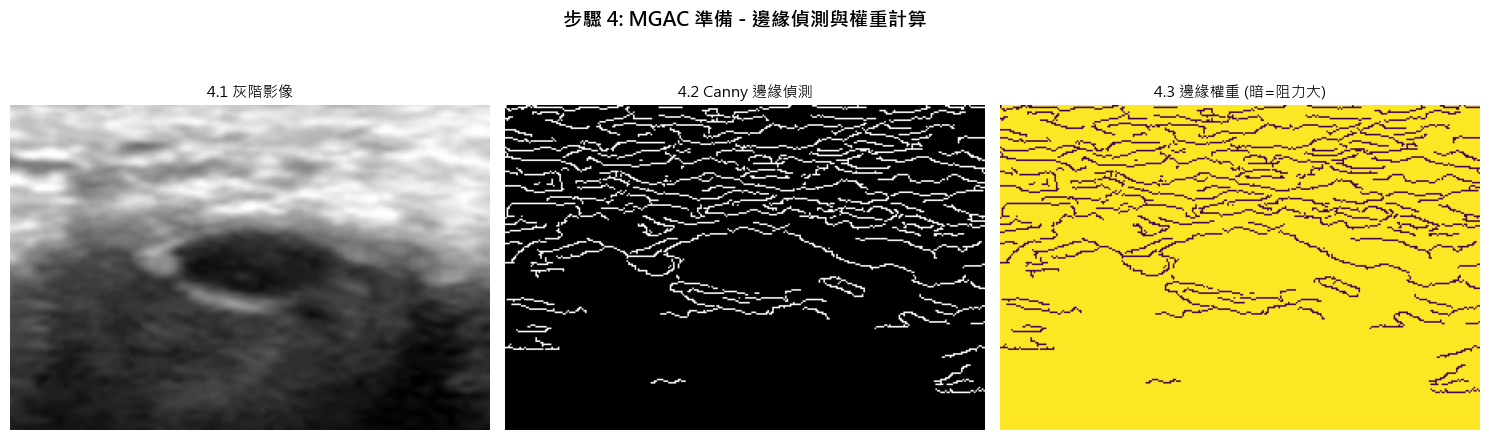

In [ ]:
# Visualize edges and weights
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_gray, cmap='gray')
axes[0].set_title('4.1 Grayscale ROI', fontsize=11)
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('4.2 Canny edges', fontsize=11)
axes[1].axis('off')

axes[2].imshow(edge_weight, cmap='viridis')
axes[2].set_title('4.3 Edge weights (dark = high resistance)', fontsize=11)
axes[2].axis('off')

plt.suptitle('Step 4: MGAC preparation – edges and weights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('2_mgac_edge_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 4.3: run MGAC contour evolution
mask_bool = grabcut_mask > 0
num_iter = 80  # Number of iterations

# Record evolution snapshots
evolution_stages = []
stage_iters = [0, 20, 40, 60, num_iter]

current_mask = mask_bool.copy()
evolution_stages.append(current_mask.copy())

for i, target_iter in enumerate(stage_iters[1:]):
    prev_iter = stage_iters[i]
    steps = target_iter - prev_iter
    current_mask = morphological_geodesic_active_contour(
        edge_weight,
        steps,
        init_level_set=current_mask,
        smoothing=1,
        threshold='auto',
        balloon=-1,
    )
    evolution_stages.append(current_mask.copy())

mgac_mask = (current_mask.astype(np.uint8) * 255)
print(f"MGAC complete: foreground pixels = {np.count_nonzero(mgac_mask)}")

MGAC 完成: 前景像素數 = 5519


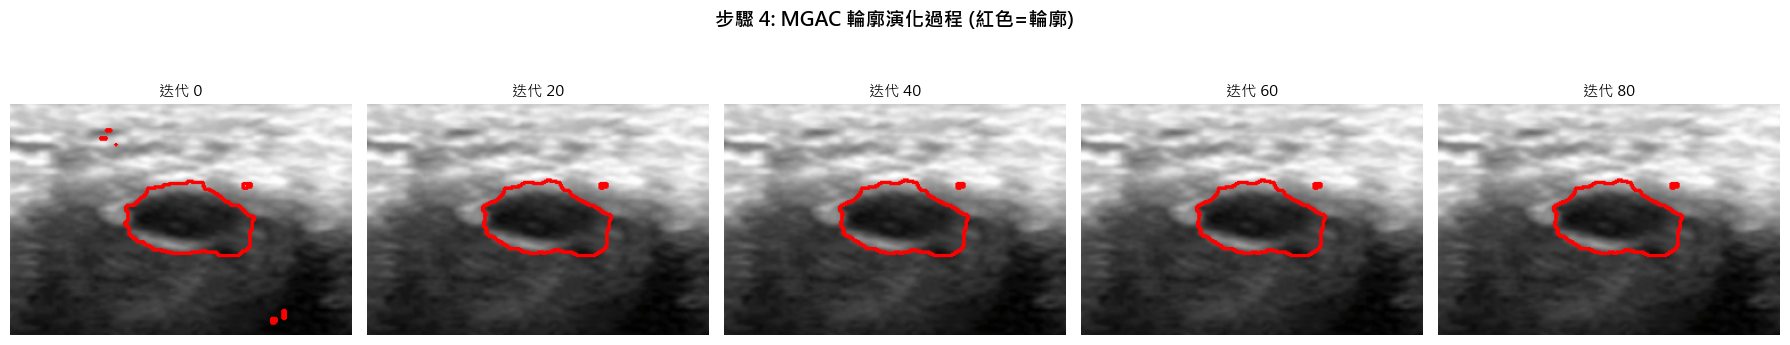

In [ ]:
# Visualize MGAC evolution
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, (stage, ax, iter_num) in enumerate(zip(evolution_stages, axes, stage_iters)):
    # Draw contours on the original ROI
    display = roi.copy()
    contours, _ = cv2.findContours(
        (stage > 0).astype(np.uint8) * 255,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(display, contours, -1, (255, 0, 0), 2)

    ax.imshow(display)
    ax.set_title(f'Iteration {iter_num}', fontsize=11)
    ax.axis('off')

plt.suptitle('Step 4: MGAC evolution (red = contour)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('3_mgac_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

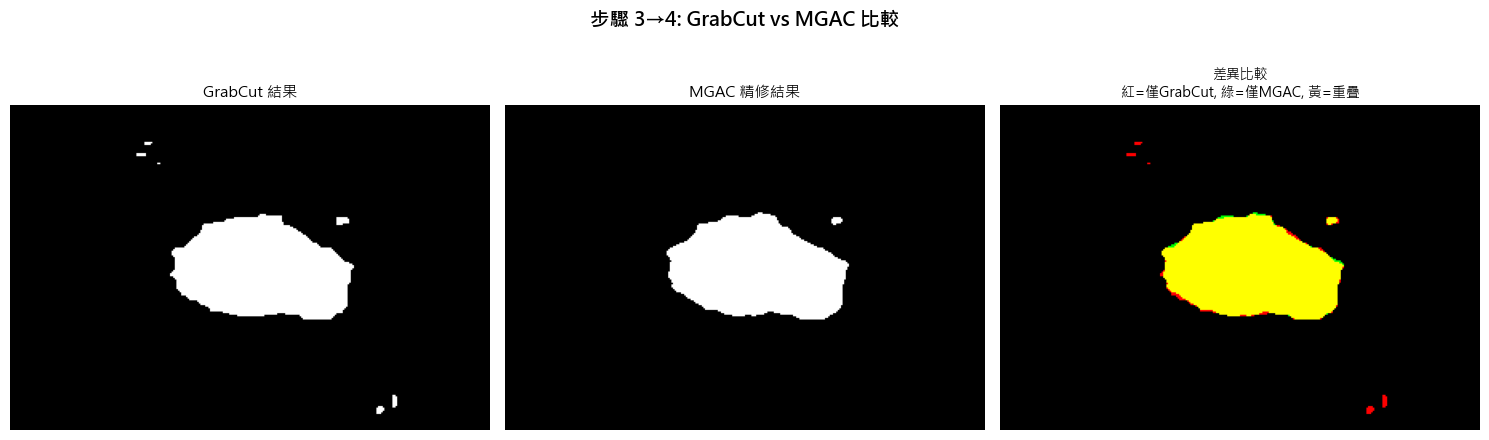

In [ ]:
# Compare GrabCut and MGAC
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(grabcut_mask, cmap='gray')
axes[0].set_title('GrabCut result', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mgac_mask, cmap='gray')
axes[1].set_title('MGAC refined result', fontsize=11)
axes[1].axis('off')

# Difference visualization
diff = np.zeros((*grabcut_mask.shape, 3), dtype=np.uint8)
diff[..., 0] = grabcut_mask  # GrabCut in red
diff[..., 1] = mgac_mask     # MGAC in green
axes[2].imshow(diff)
axes[2].set_title('Difference\nRed=only GrabCut, Green=only MGAC, Yellow=overlap', fontsize=10)
axes[2].axis('off')

plt.suptitle('Step 3 → 4: GrabCut vs MGAC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('4_grabcut_vs_mgac.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Post-processing

Post-processing is composed of three sub-steps:

### 5.1 Morphological operations
- **Opening**: removes tiny noise speckles.
- **Closing**: fills small holes inside the mask.

### 5.2 Guided filtering
- Uses the original grayscale image as guidance.
- Aligns mask edges with image textures for cleaner boundaries.

### 5.3 Connected-component filtering
- Removes components that touch the ROI boundary.
- Keeps only the largest remaining component.

In [ ]:
# Step 5.1: morphological operations
kernel = np.ones((3, 3), np.uint8)

# Opening – remove small noise
mask_open = cv2.morphologyEx(mgac_mask, cv2.MORPH_OPEN, kernel)

# Closing – fill small holes
mask_morph = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel)

print(f"After morphology: foreground pixels = {np.count_nonzero(mask_morph)}")

形態學處理後: 前景像素數 = 5512


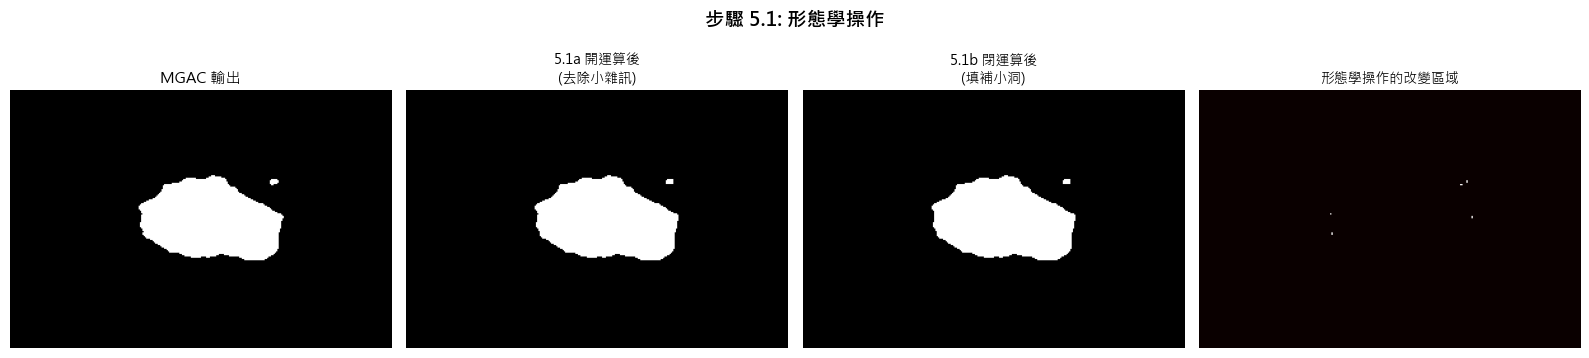

In [ ]:
# Visualize morphological operations
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(mgac_mask, cmap='gray')
axes[0].set_title('MGAC output', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mask_open, cmap='gray')
axes[1].set_title('5.1a After opening\n(noise removed)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(mask_morph, cmap='gray')
axes[2].set_title('5.1b After closing\n(holes filled)', fontsize=10)
axes[2].axis('off')

# Difference map
diff_morph = np.abs(mgac_mask.astype(np.int16) - mask_morph.astype(np.int16)).astype(np.uint8)
axes[3].imshow(diff_morph, cmap='hot')
axes[3].set_title('Pixels changed by morphology', fontsize=10)
axes[3].axis('off')

plt.suptitle('Step 5.1: Morphological operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('5_morphology.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 5.2: guided filtering
guided = guided_filter(roi_gray, mask_morph / 255.0, radius=4, eps=1e-3)
mask_guided = (guided > 0.5).astype(np.uint8) * 255

print(f"After guided filtering: foreground pixels = {np.count_nonzero(mask_guided)}")

導向濾波後: 前景像素數 = 5467


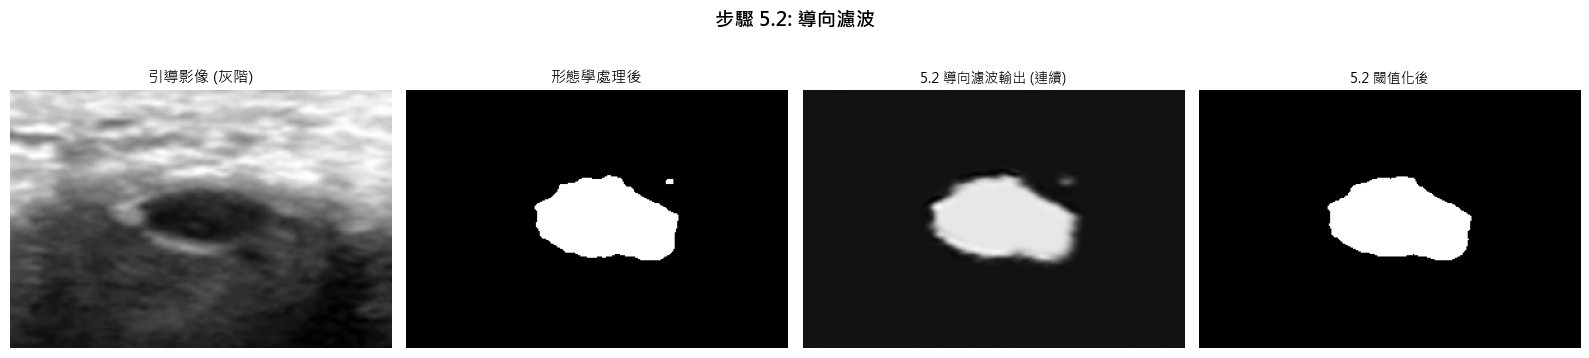

In [ ]:
# Visualize guided filtering
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(roi_gray, cmap='gray')
axes[0].set_title('Guidance image (grayscale)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mask_morph, cmap='gray')
axes[1].set_title('Post-morphology mask', fontsize=11)
axes[1].axis('off')

axes[2].imshow(guided, cmap='gray')
axes[2].set_title('5.2 Guided filter output (continuous)', fontsize=10)
axes[2].axis('off')

axes[3].imshow(mask_guided, cmap='gray')
axes[3].set_title('5.2 After thresholding', fontsize=10)
axes[3].axis('off')

plt.suptitle('Step 5.2: Guided filtering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('6_guided_filter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 5.3: connected-component filtering

# Remove components touching the ROI boundary
mask_no_boundary = remove_boundary_components(mask_guided)

# Keep only the largest component
final_mask = largest_component(mask_no_boundary)

print(f"Final mask: foreground pixels = {np.count_nonzero(final_mask)}")

最終遮罩: 前景像素數 = 5467


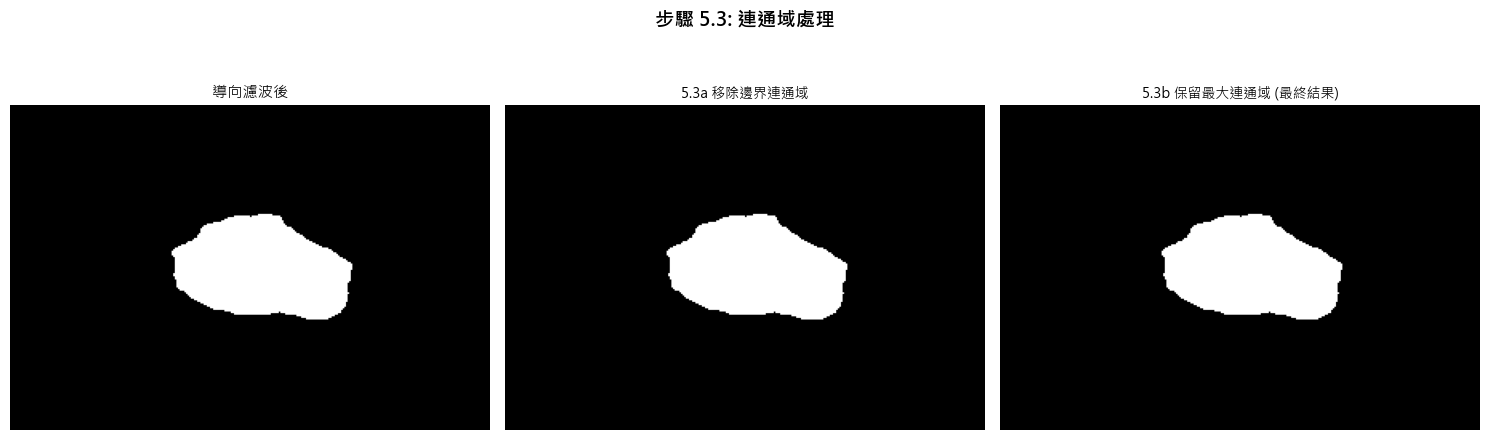

In [ ]:
# Visualize connected-component filtering
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_guided, cmap='gray')
axes[0].set_title('After guided filtering', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mask_no_boundary * 255, cmap='gray')
axes[1].set_title('5.3a Remove boundary-touching components', fontsize=10)
axes[1].axis('off')

axes[2].imshow(final_mask, cmap='gray')
axes[2].set_title('5.3b Keep largest component (final mask)', fontsize=10)
axes[2].axis('off')

plt.suptitle('Step 5.3: Connected-component processing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('7_connected_components.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Full pipeline overview

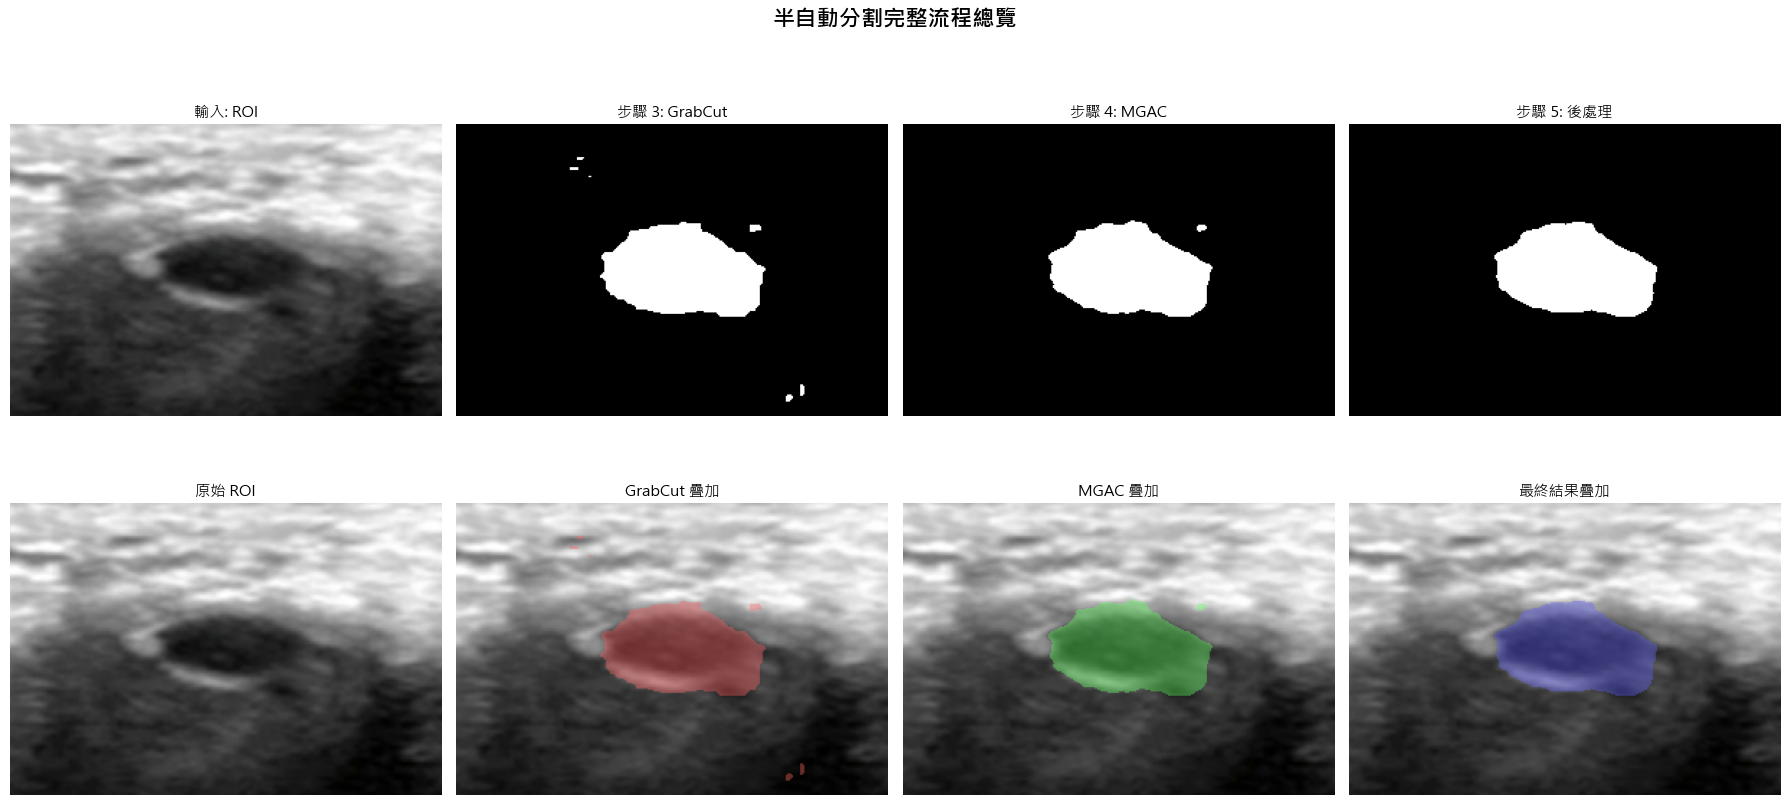

In [ ]:
# Final pipeline visualization
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# First row: individual steps
axes[0, 0].imshow(roi)
axes[0, 0].set_title('Input: ROI', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(grabcut_mask, cmap='gray')
axes[0, 1].set_title('Step 3: GrabCut', fontsize=11)
axes[0, 1].axis('off')

axes[0, 2].imshow(mgac_mask, cmap='gray')
axes[0, 2].set_title('Step 4: MGAC', fontsize=11)
axes[0, 2].axis('off')

axes[0, 3].imshow(final_mask, cmap='gray')
axes[0, 3].set_title('Step 5: Post-processing', fontsize=11)
axes[0, 3].axis('off')

# Second row: overlays
def overlay_mask(image, mask, color=[255, 0, 0], alpha=0.4):
    """Overlay a mask on the image."""
    overlay = image.copy()
    mask_bool = mask > 0
    overlay[mask_bool] = np.array(color)
    return cv2.addWeighted(image, 1 - alpha, overlay, alpha, 0)

axes[1, 0].imshow(roi)
axes[1, 0].set_title('Raw ROI', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(overlay_mask(roi, grabcut_mask, [255, 100, 100]))
axes[1, 1].set_title('GrabCut overlay', fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(overlay_mask(roi, mgac_mask, [100, 255, 100]))
axes[1, 2].set_title('MGAC overlay', fontsize=11)
axes[1, 2].axis('off')

axes[1, 3].imshow(overlay_mask(roi, final_mask, [100, 100, 255]))
axes[1, 3].set_title('Final overlay', fontsize=11)
axes[1, 3].axis('off')

plt.suptitle('Semi-automatic segmentation overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('8_complete_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

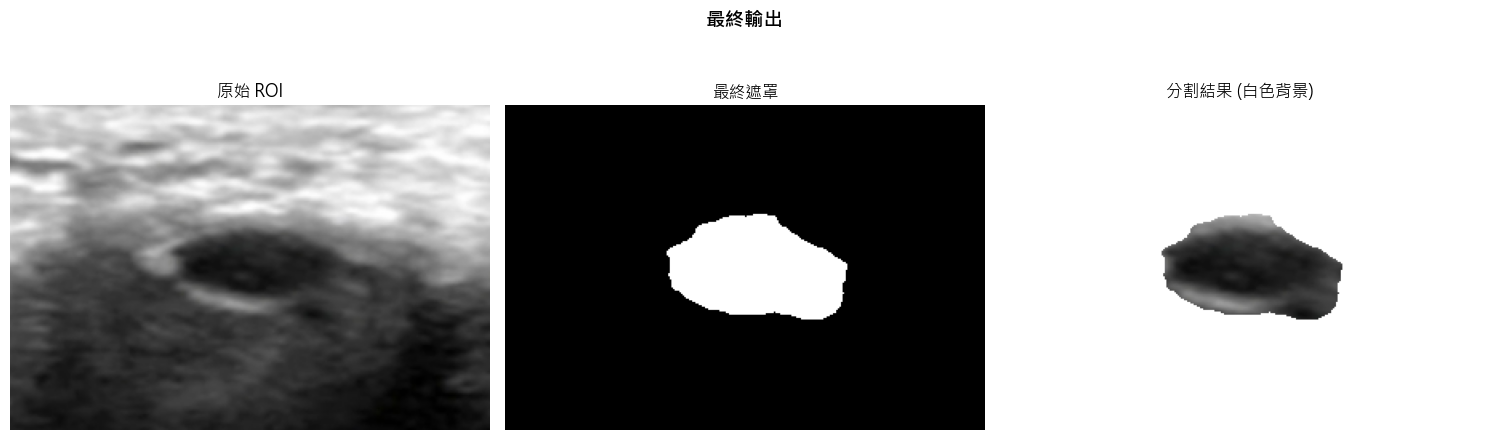


已儲存的檔案:
- final_mask.png: 最終二值遮罩
- segmented_result.png: 分割結果 (白色背景)


In [ ]:
# Export the final mask and segmented output
cv2.imwrite('final_mask.png', final_mask)

# Apply mask to extract the object
segmented = roi.copy()
segmented[final_mask == 0] = [255, 255, 255]  # Set background to white

# Create an RGBA version for transparency
segmented_rgba = np.zeros((*roi.shape[:2], 4), dtype=np.uint8)
segmented_rgba[..., :3] = roi
segmented_rgba[..., 3] = final_mask

cv2.imwrite('segmented_result.png', cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi)
axes[0].set_title('Raw ROI', fontsize=12)
axes[0].axis('off')

axes[1].imshow(final_mask, cmap='gray')
axes[1].set_title('Final mask', fontsize=12)
axes[1].axis('off')

axes[2].imshow(segmented)
axes[2].set_title('Segmented result (white background)', fontsize=12)
axes[2].axis('off')

plt.suptitle('Final outputs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('9_final_output.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved files:")
print("- final_mask.png: final binary mask")
print("- segmented_result.png: segmented ROI on white background")

---
## Summary

### Why is this considered "semi-automatic" or "unsupervised" segmentation?

1. **No pixel-level labels required**: the workflow only needs a bounding box hint for the object; no manual masks are needed for training.

2. **Relies on image cues**:
   - GrabCut: analyzes color distributions.
   - MGAC: leverages edge information.
   - Guided filtering: follows local texture cues.

3. **Generalizable**: the algorithms work on any object/category without class-specific training.

### Role of each step

| Step | Algorithm | Purpose |
|------|-----------|---------|
| 3 | GrabCut | Produce the coarse mask |
| 4 | MGAC | Align the boundary to object contours |
| 5 | Post-processing | Remove noise and polish edges |